Mount google drive

In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


STEP 1 — Import Libraries and Load CSV

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Load CSV
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

# Display first 5 rows
df.head()

Saving credit_risk_dataset.csv.zip to credit_risk_dataset.csv.zip
Dataset loaded successfully!
Dataset Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


STEP 2 — Understand Dataset

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Number of Rows: 32581
Number of Columns: 12

Column Names:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   l

In [ ]:
# Statistical summary

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,32581.0,NaN,NaN,NaN,27.7346,6.348078,20.0,23.0,26.0,30.0,144.0
person_income,32581.0,NaN,NaN,NaN,66074.84847,61983.119168,4000.0,38500.0,55000.0,79200.0,6000000.0
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,31686.0,NaN,NaN,NaN,4.789686,4.14263,0.0,2.0,4.0,7.0,123.0
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,32581.0,NaN,NaN,NaN,9589.371106,6322.086646,500.0,5000.0,8000.0,12200.0,35000.0
loan_int_rate,29465.0,NaN,NaN,NaN,11.011695,3.240459,5.42,7.9,10.99,13.47,23.22
loan_status,32581.0,NaN,NaN,NaN,0.218164,0.413006,0.0,0.0,0.0,0.0,1.0
loan_percent_income,32581.0,NaN,NaN,NaN,0.170203,0.106782,0.0,0.09,0.15,0.23,0.83


STEP 3 — Data Cleaning



Check missing values

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Check duplicates

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 165


Remove duplicates

In [ ]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (32416, 12)


Fill missing values

In [ ]:
# Fill numerical missing values with median
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

# Fill categorical missing values with mode
categorical_columns = df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


/tmp/ipykernel_1865/1607791999.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].fillna(
/tmp/ipykernel_1865/1607791999.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[column] = df[column].fillna(


STEP 4 — Exploratory Data Analysis













Target variable

Your target column is:

In [ ]:
print(df["loan_status"].value_counts())

loan_status
0    25327
1     7089
Name: count, dtype: int64


Target distribution

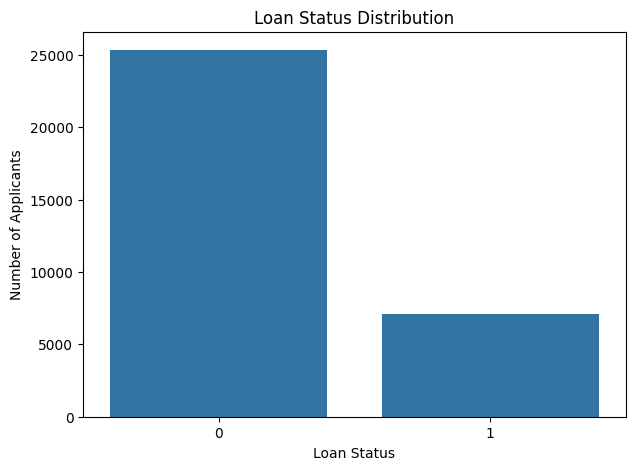

In [ ]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="loan_status"
)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

Target percentage

In [ ]:
print(
    df["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

loan_status
0    78.13
1    21.87
Name: proportion, dtype: float64


Credit Score Distribution

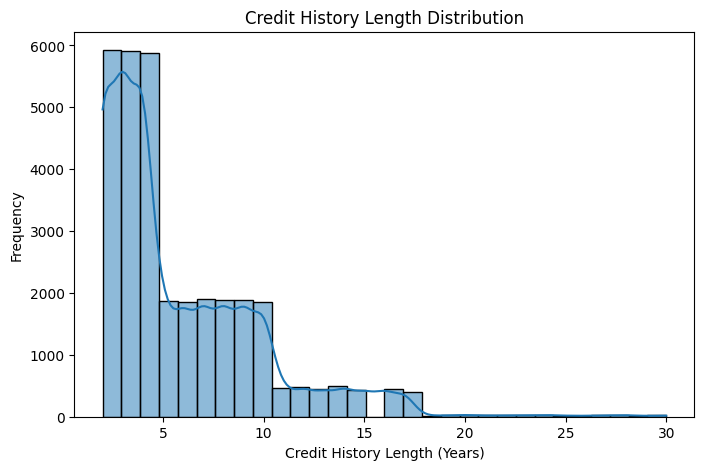

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["cb_person_cred_hist_length"],
    bins=30,
    kde=True
)

plt.title("Credit History Length Distribution")
plt.xlabel("Credit History Length (Years)")
plt.ylabel("Frequency")

plt.show()

Annual Income Distribution

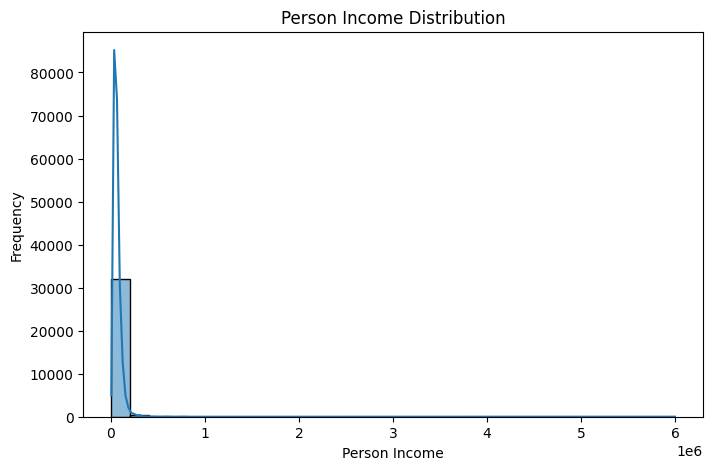

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["person_income"],
    bins=30,
    kde=True
)

plt.title("Person Income Distribution")
plt.xlabel("Person Income")
plt.ylabel("Frequency")

plt.show()

Loan Amount Distribution

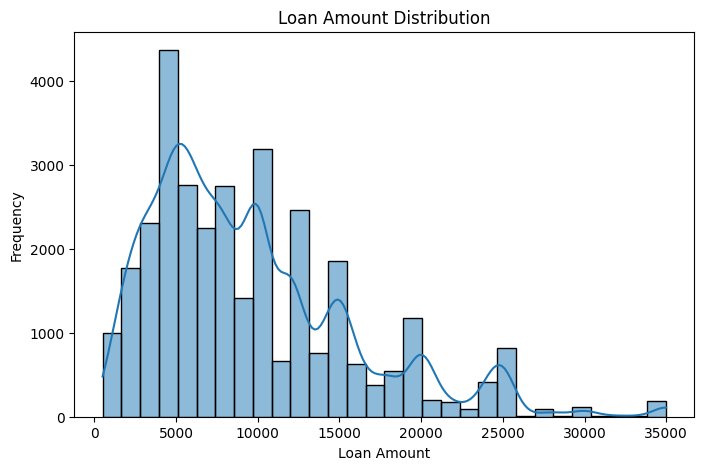

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["loan_amnt"],
    bins=30,
    kde=True
)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")

plt.show()

STEP 5 — Prepare Features and Target

For Version 1, we will keep the feature preparation simple.


In [ ]:
target = "loan_status"

X = df.drop(
    columns=[
        "loan_status",
        "person_age", # Drop person_age, as its maximum value is 144, which is not realistic and can skew the data.
        "applicant_id", # This column was not found in the original df columns
        "credit_score", # This column was not found in the original df columns
        "risk_tier" # This column was not found in the original df columns
    ],
    errors="ignore"
)

y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

Features shape: (32416, 10)
Target shape: (32416,)

Target values:
loan_status
0    25327
1     7089
Name: count, dtype: int64


STEP 6 — Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (25932, 10)
Testing data: (6484, 10)


STEP 7 — Data Preprocessing

Separate numerical and categorical columns.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']

Categorical Features:
['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


Preprocessing

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


STEP 8 — Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logistic_model.fit(
    X_train,
    y_train
)

print("Logistic Regression training completed!")

Logistic Regression training completed!


STEP 9 — Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=8,
            random_state=42
        )
    )
])

decision_tree_model.fit(
    X_train,
    y_train
)

print("Decision Tree training completed!")

Decision Tree training completed!


STEP 10 — Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        )
    )
])

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed!")

Random Forest training completed!


STEP 11 — Model Evaluation

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_test, y_test):

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    return [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]


STEP 12 — Compare Models

In [ ]:
logistic_results = evaluate_model(
    logistic_model,
    X_test,
    y_test
)

decision_tree_results = evaluate_model(
    decision_tree_model,
    X_test,
    y_test
)

random_forest_results = evaluate_model(
    random_forest_model,
    X_test,
    y_test
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_results[0],
        decision_tree_results[0],
        random_forest_results[0]
    ],

    "Precision": [
        logistic_results[1],
        decision_tree_results[1],
        random_forest_results[1]
    ],

    "Recall": [
        logistic_results[2],
        decision_tree_results[2],
        random_forest_results[2]
    ],

    "F1 Score": [
        logistic_results[3],
        decision_tree_results[3],
        random_forest_results[3]
    ],

    "ROC-AUC": [
        logistic_results[4],
        decision_tree_results[4],
        random_forest_results[4]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.869217,0.772989,0.569111,0.655565,0.867901
1,Decision Tree,0.929365,0.971513,0.697461,0.811987,0.896326
2,Random Forest,0.934146,0.971456,0.720028,0.827055,0.925355


STEP 13 — Classification Report

In [ ]:
# ============================================
# STEP 13: CLASSIFICATION REPORT
# ============================================

from sklearn.metrics import classification_report

print("===== LOGISTIC REGRESSION =====")
print(
    classification_report(
        y_test,
        logistic_model.predict(X_test)
    )
)

print("\n===== DECISION TREE =====")
print(
    classification_report(
        y_test,
        decision_tree_model.predict(X_test)
    )
)

print("\n===== RANDOM FOREST =====")
print(
    classification_report(
        y_test,
        random_forest_model.predict(X_test)
    )
)

===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5066
           1       0.77      0.57      0.66      1418

    accuracy                           0.87      6484
   macro avg       0.83      0.76      0.79      6484
weighted avg       0.86      0.87      0.86      6484


===== DECISION TREE =====
              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5066
           1       0.97      0.70      0.81      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.85      0.88      6484
weighted avg       0.93      0.93      0.92      6484


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5066
           1       0.97      0.72      0.83      1418

    accuracy                           0.93      6484
   macro avg       0.95      0.86      0.8

STEP 14 — Confusion Matrix

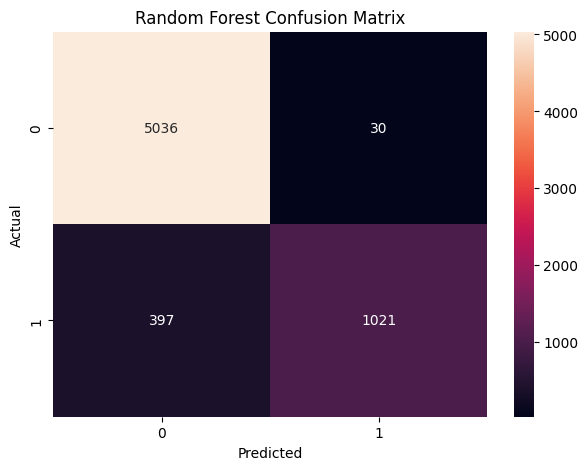

In [ ]:
# ============================================
# STEP 14: CONFUSION MATRIX
# ============================================

from sklearn.metrics import confusion_matrix

y_pred_rf = random_forest_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

STEP 15 — ROC Curve

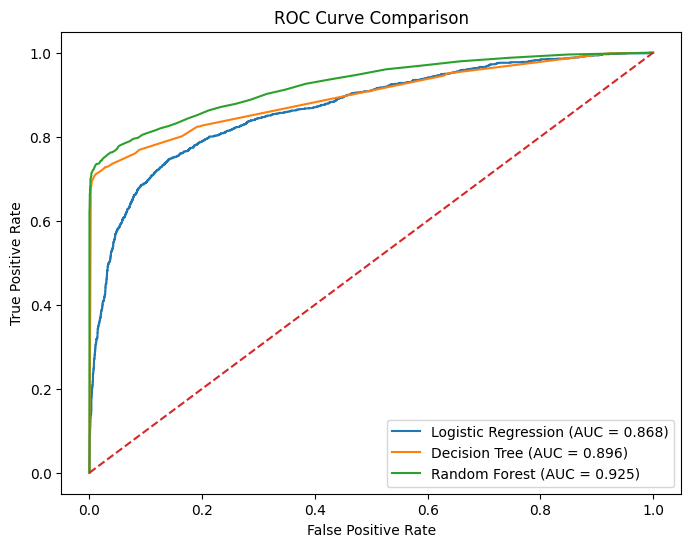

In [ ]:
# ============================================
# STEP 15: ROC CURVE
# ============================================

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

for name, model in models.items():

    y_probability = model.predict_proba(
        X_test
    )[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_probability
    )

    auc = roc_auc_score(
        y_test,
        y_probability
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

STEP 16 — Feature Importance

In [ ]:
# ============================================
# STEP 16: FEATURE IMPORTANCE
# ============================================

rf_model = random_forest_model.named_steps["model"]

preprocessor_fitted = (
    random_forest_model
    .named_steps["preprocessor"]
)

feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,numeric__loan_percent_income,0.233479
0,numeric__person_income,0.144827
3,numeric__loan_int_rate,0.119413
2,numeric__loan_amnt,0.079074
1,numeric__person_emp_length,0.066525
9,categorical__person_home_ownership_RENT,0.055061
19,categorical__loan_grade_D,0.052460
5,numeric__cb_person_cred_hist_length,0.043006
6,categorical__person_home_ownership_MORTGAGE,0.028224
10,categorical__loan_intent_DEBTCONSOLIDATION,0.023006


Plot

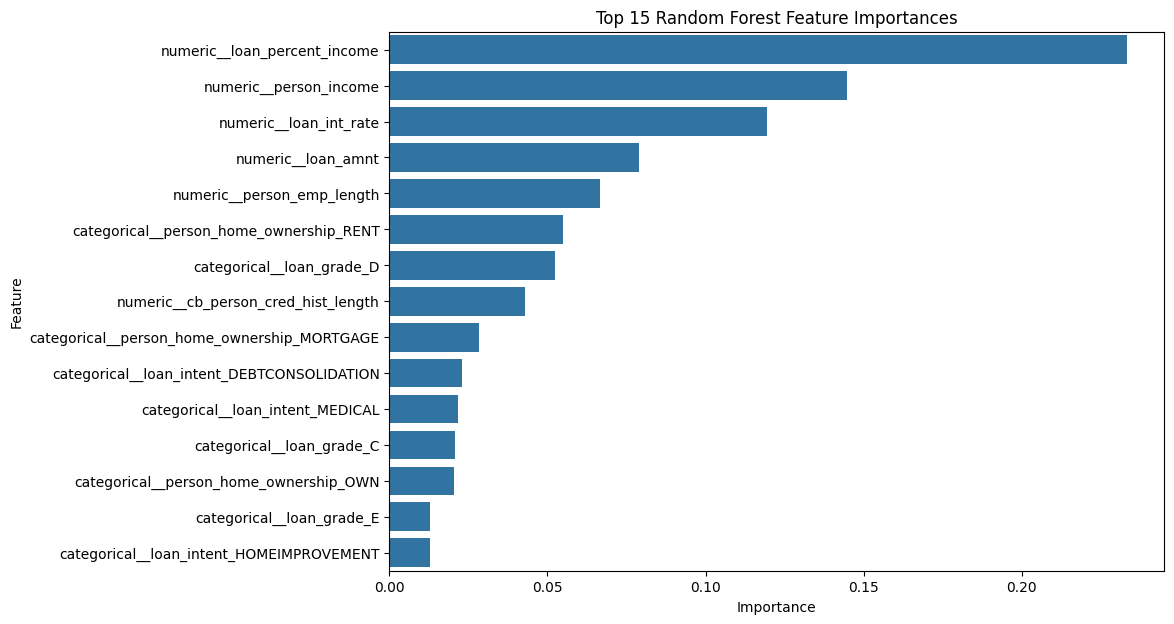

In [ ]:
plt.figure(figsize=(10,7))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Random Forest Feature Importances"
)

plt.show()

STEP 17 — Select Final Model

In [ ]:
# ============================================
# STEP 17: MODEL COMPARISON
# ============================================

results_sorted = results.sort_values(
    by="ROC-AUC",
    ascending=False
)

results_sorted

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Random Forest,0.934146,0.971456,0.720028,0.827055,0.925355
1,Decision Tree,0.929365,0.971513,0.697461,0.811987,0.896326
0,Logistic Regression,0.869217,0.772989,0.569111,0.655565,0.867901


Display the model with the highest measured ROC-AUC:

In [ ]:
best_model_name = results_sorted.iloc[0]["Model"]

print("Model with highest ROC-AUC in this test set:")
print(best_model_name)

Model with highest ROC-AUC in this test set:
Random Forest


STEP 18 — New Applicant Prediction

In [ ]:
# ============================================
# STEP 18: NEW APPLICANT PREDICTION
# ============================================

sample_applicant = X_test.iloc[[0]]

prediction = random_forest_model.predict(
    sample_applicant
)[0]

probability = random_forest_model.predict_proba(
    sample_applicant
)[0][1]

print("Prediction:", prediction)
print("Probability:", round(probability, 4))

Prediction: 0
Probability: 0.4


STEP 19 — Save Final Model

In [ ]:
# ============================================
# STEP 19: SAVE MODEL
# ============================================

import joblib

joblib.dump(
    random_forest_model,
    "credit_scoring_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


STEP 20 — Save Results

In [ ]:
# ============================================
# STEP 20: SAVE RESULTS
# ============================================

results.to_csv(
    "credit_scoring_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "credit_scoring_feature_importance.csv",
    index=False
)

print("Result files saved successfully!")

Result files saved successfully!
